# PCA as an Example of Factor Model

## 基于 PCA 的因子模型:  
(1) 使用主成分分析 (PCA), 从中证 1000 小盘股股票池日收益率数据中提取公共的主要风险因子。  
(2) 基于这些因子建立各股票的收益率的线性回归模型, 预测各股票的"正常"收益率。  
(3) 做多过去一段时间累计预测收益率最好的股票, 做空过去一段时间累计预测收益率最差的股票（动量趋势策略）。  
(4) 计算该策略的部分回测指标。  

In [1]:
import math
import sys, os

# 把工程根目录加入 sys.path（notebooks 的上一级目录）
project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.append(project_root)

In [2]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.multioutput import MultiOutputRegressor
from sklearn.decomposition import PCA
from src.calculateMaxDD import calculateMaxDD

## 1. 数据准备和预处理
- 设置基本参数:  
  lookback : 训练期时段天数, 252  
  numFactors : 主成分因子个数, 5  
  topN : 每天做多/做空的股票支数, 50  
- df : 中证 1000 小盘股的历史股价  
  是带日期索引的 DataFrame  
- dailyRet : 股票的日收益率数据  
  是带日期索引的 DataFrame
- positionsTable : 头寸(仓位)表  
  二维数组, 用于存储每支股票在每一天的持仓数, 初始值均是 0 (空仓)  
- end_index : 循环截止的索引号  
  等于天数  

In [3]:
# Config
lookback = 252   # 训练期，使用过去252个交易日的数据
numFactors = 5   # 使用5个主成分作为因子
topN = 50   # 做多/做空各50支股票

# 确保结果输出目录存在
results_dir = os.path.join(project_root, "results")
os.makedirs(results_dir, exist_ok=True)

In [4]:
# Data preprocess
df = pd.read_csv('../data/sample/zhongzheng-1000.csv') 
df["trade_date"].dtype 

dtype('O')

In [5]:
df["trade_date"] = pd.to_datetime(df["trade_date"])
df['trade_date'] = df['trade_date'].dt.strftime("%Y%m%d")
df.set_index('trade_date', inplace=True)
df.sort_index(inplace=True)
df.ffill(inplace=True)   
# forward fill 向前填充，若某单元格为NaN（无效数据），则以其上一个单元格（上一行、同列的单元格）值填充

dailyRet = df.pct_change()   
positionsTable = np.zeros(df.shape)
expRetTable = np.zeros(df.shape)   
end_index = df.shape[0]  

## 2. 计算头寸（仓位）
循环计算得到索引号从 lookback+1 至 end_index-1 每一天的头寸(仓位), 具体如下:  
(1) 每天提取所有股票在此之前最新的 lookback 条历史日收益率数据作为训练集, 转置后赋予变量 R  
&nbsp;&nbsp;&nbsp;&nbsp;R 是 DataFrame 类型  
&nbsp;&nbsp;&nbsp;&nbsp;在处理过程中需剔除缺数据的股票, 因此, 行数(股数)可能会小于总股票数。  
&nbsp;&nbsp;&nbsp;&nbsp;变量 hasData 是一维数组，用于存储训练集 R 中所有不包含 NaN 的行(股票)的行索引号(对应某一支股票)。  
(2) 使用主成分分析 (PCA) 方法, 对训练集中的各股票的252天的日收益率数据进行分析计算  
&nbsp;&nbsp;&nbsp;&nbsp;得到所有这些股票所共有的主要风险因子(因子收益), 作为属性值, 赋予变量 X  
&nbsp;&nbsp;&nbsp;&nbsp;X 是 二维数组, 252 行(天), 6 列 (其中首列是常数项1, 主成分因子个数是5)。  
(3) 把提及的股票的训练集中的日收益率数据, 作为标签值, 赋予变量 Y  
(4) 创建线性回归模型 Y = X W + ε, 拟合计算得到各股票的各因子的权重 W, 赋予变量 clf  
(5) 通过所得到的各股票的回归模型 clf, 根据共有的风险因子(因子收益) X, 计算各股票在之前252天的每一天的拟合值  
&nbsp;&nbsp;&nbsp;&nbsp;把各股票这252天拟合值分别加 1 求积, 作为各股票预测的累计涨跌幅指标, 赋予变量 cumExpRet  
&nbsp;&nbsp;&nbsp;&nbsp;cumExpRet 是一维数组, 其长度提及的股票数。  
(6) 把预测的累计涨跌幅指标 cumExpRet 从小到大排序, 做空最前面 50 种股票, 做多最后面50种股票  
&nbsp;&nbsp;&nbsp;&nbsp;据此修改头寸(仓位)表 positionsTable 中该天所对应股票的头寸(仓位)。  

In [6]:
for t in np.arange(lookback + 1, end_index):    # 从第 lookback+1 日开始，每一日都要重新建模
    if (t % 50 == 0):
        print(str(t),  '/', str(end_index))  # 显示训练进度
    R = dailyRet.iloc[t - lookback : t,].T    
    # .T 表示转置，R 每一行对应一支股票，每一列对应一天
    # 转置是为了后续删除整行数据更方便，做 PCA 时要重新转置回来
    hasData = np.where(R.notna().all(axis = 1))[0]
    # .all(axis=1)：在“行”这个维度上做 and 聚合。结果是一个一维布尔数组/Series，长度等于行数；True 表示这一整行都没有缺失值。
    # np.where( ... )：对这个一维布尔数组，返回“为 True 的位置的下标”。
    # [0]：取出元组里的第一个元素，也就是实际的下标数组。
    # hasData 最终是一个一维的 numpy 数组，里面存的是所有“没有任何 NaN 的行”的行索引。   
    R.dropna(inplace = True)   
    # 删除 NaN（无效数据）单元格所在的行，即删除对应整支股票
    # “inplace = True” 在原对象上直接修改，不再返回一个新的对象。
    pca = PCA()  # 调用主成分分析，本例中的因子收益是通过主成分分析得到的
    X = pca.fit_transform(R.T)[:, :numFactors]  # X 是主成分（因子），每一行对应一天，每一列是一个因子
    X = sm.add_constant(X)  # 把常数项 1 插入到 X 的首列，这样后续回归计算将会得到常数项 1 对应的系数(即常数项值)
    Y = R.T  # y1 是 DataFrame, 每一行对应一天，每一列对应一支股票
    clf = MultiOutputRegressor(LinearRegression(fit_intercept = False), n_jobs = -1).fit(X, Y)  
    # 创建并拟合得到各股票的线性回归模型 （模型数 = 股票数）
    avgExpRet = np.mean(clf.predict(X), axis=0)   
    # 对每支股票在训练时段内每一天的模型预测的收益率值平均，以此作为该股票在该时间段所预测的累计涨跌幅指    
    expRetTable[t, hasData] = avgExpRet
    # 把该日所有有完整数据股票的预期涨跌幅写入 expRetTable 对应行
    idxSort = avgExpRet.argsort()  
    # idxSort 是一个索引数组，表示把 cumExpRet 从小到大排序后，各股票的排序位置。
    positionsTable[t, hasData[idxSort[np.arange(0, topN)]]] = -1    
    # 对应 topN 支股票在训练时段预测的累计跌幅最大，按趋势预计还要跌，所以做空。
    positionsTable[t, hasData[idxSort[np.arange(-topN, 0)]]] = 1    
    # 对应 topN 支股票在训练时段预测的累计涨幅最大，按趋势预计还要涨，所以做多。


300 / 1455
350 / 1455
400 / 1455
450 / 1455
500 / 1455
550 / 1455
600 / 1455
650 / 1455
700 / 1455
750 / 1455
800 / 1455
850 / 1455
900 / 1455
950 / 1455
1000 / 1455
1050 / 1455
1100 / 1455
1150 / 1455
1200 / 1455
1250 / 1455
1300 / 1455
1350 / 1455
1400 / 1455
1450 / 1455


## 3. 计算不计交易成本的回测指标

### 计算夏普比率
- 计算每一天的总资本(等于持仓数的绝对值的和)<br>
- 计算日回报率 (未扣除交易成本)<br>
- 计算年化回报率<br>
  年化回报率 = 日均回报率 $\cdot$ 252  
- 计算年化回报波动率<br>
  年化回报波动率 = 日回报波动率 $\cdot$ sqrt(252)  
- 计算年化夏普比例<br>
  年化夏普比例 = 年化回报率 / 年化回报波动率

In [7]:
capital = np.nansum(np.array(abs(pd.DataFrame(positionsTable))), axis=1)  
# np.nansum(..., axis=1)：对每一行按列求和（忽略 NaN），也就是把这一日所有股票的绝对持仓量加总。
positionsTable[capital==0,] = 0   # 把 capital 值为 0 元素对应行（天）的全部持仓数均置为 0 
capital[capital==0] = 1  # 避免除以 0
ret = np.nansum(np.array(pd.DataFrame(positionsTable)) * np.array(dailyRet), axis=1) / capital  
avgRet = np.nanmean(ret) * 252   # 年化回报率
avgStdRet = np.nanstd(ret) * math.sqrt(252)   # 年化回报波动率
sharpe = avgRet / avgStdRet   # 夏普比例
print(avgRet)
print(avgStdRet)
print(sharpe)


0.05633606422158886
0.12080622426716106
0.46633411948214304


### 计算最大回撤/最大回撤持续期

In [8]:
cumRet = np.cumprod(1.0 + ret) - 1.0
maxDD, maxDDD, i = calculateMaxDD(cumRet)

print("Max Drawdown:", float(maxDD))
print("Max Drawdown Duration (days):", int(maxDDD))

Max Drawdown: -0.24923339995402072
Max Drawdown Duration (days): 671


### 绘制累积收益率图并保存

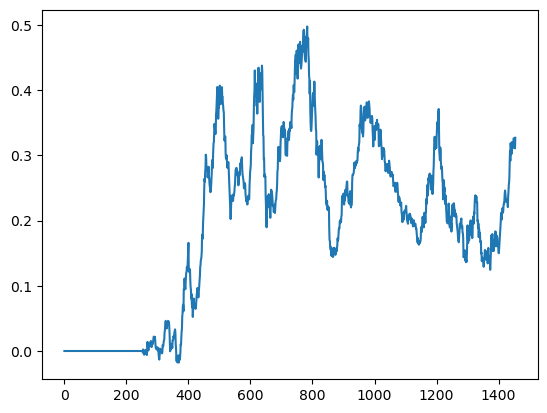

In [9]:
plt.plot(cumRet)  # 绘制累积收益率（水位线）图
plt.savefig(os.path.join(results_dir, "cumRet.png"), dpi=300, bbox_inches="tight")

### 保存回测指标

In [10]:
# 将关键回测指标汇总成 DataFrame 并导出为 CSV
metrics_df = pd.DataFrame({
    "Annualized Return": [avgRet],
    "Annualized Volatility": [avgStdRet],
    "Sharpe Ratio": [sharpe],
    "Max Drawdown": [maxDD],
    "Max Drawdown Duration": [maxDDD],
})
metrics_df.to_csv(os.path.join(results_dir, "metrics_summary.csv"), index=False)


### 保存收益率表、仓位表和预期收益率表

In [11]:
positionsTable = pd.DataFrame(positionsTable, index=df.index, columns=df.columns)
expRetTable = pd.DataFrame(expRetTable, index=df.index, columns=df.columns)

dailyRet.to_csv(os.path.join(results_dir, "dailyRet.csv"))
positionsTable.to_csv(os.path.join(results_dir, "positions.csv"))
expRetTable.to_csv(os.path.join(results_dir, "expRet.csv"))